In [13]:
# If you are using google colab, you can mount your google drive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Fine-tuning
This notebook demonstrates fine-tuning RamanFoundation on the Bacteria-ID dataset from Ho et al. (2019).

In [14]:
# From https://github.com/csho33/bacteria-ID
!unzip '/content/drive/My Drive/data.zip'

unzip:  cannot find or open /content/drive/My Drive/data.zip, /content/drive/My Drive/data.zip.zip or /content/drive/My Drive/data.zip.ZIP.


In [15]:
# This may be colab-specific. You may need to adapt this if you are running locally
!pip install tf_keras

!export TF_USE_LEGACY_KERAS=1
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf #importing tensorflow after setting the environment variable is important

import tensorflow as tf
import tf_keras as keras
print(tf.__version__)
print(keras.__version__)

!pip install tensorflow-addons

2.20.0
2.20.0
ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


In [16]:
import os
import numpy as np  # np.random.random
import matplotlib.pyplot as plt  # graphs
import datetime  # tensorboard logs naming

In [17]:
import os
import numpy as np

data_dir = '/content/drive/My Drive/Tesi_Raman/Datasets/Bacteria-ID/'

x_2018clinical = np.load(data_dir + 'X_2018clinical.npy')
y_2018clinical = np.load(data_dir + 'y_2018clinical.npy')
x_2019clinical = np.load(data_dir + 'X_2019clinical.npy')
y_2019clinical = np.load(data_dir + 'y_2019clinical.npy')

x_finetune = np.load(data_dir + 'X_finetune.npy')
y_finetune = np.load(data_dir + 'y_finetune.npy')

x_reference = np.load(data_dir + 'X_reference.npy')
y_reference = np.load(data_dir + 'y_reference.npy')

x_test = np.load(data_dir + 'X_test.npy')
y_test = np.load(data_dir + 'y_test.npy')

def shuffle_in_place(x, y):
  combined_data = np.column_stack((x, y))
  np.random.shuffle(combined_data)
  x_shuffled = combined_data[:, :-1]
  y_shuffled = combined_data[:, -1]
  return x_shuffled, y_shuffled


x_reference_shuffled, y_reference_shuffled = shuffle_in_place(x_reference, y_reference)
x_finetune_shuffled, y_finetune_shuffled = shuffle_in_place(x_finetune, y_finetune)
x_test_shuffled, y_test_shuffled = shuffle_in_place(x_test, y_test)

x_reference, y_reference = x_reference_shuffled, y_reference_shuffled
x_finetune, y_finetune = x_finetune_shuffled, y_finetune_shuffled
x_test, y_test = x_test_shuffled, y_test_shuffled


wavenumbers = np.load(data_dir + 'wavenumbers.npy')


In [18]:
class ResNet34Old:
    """Resnet34 class.
        Responsible for the Resnet 34 architecture.
    Modified from
    https://www.analyticsvidhya.com/blog/2021/08/how-to-code-your-resnet-from-scratch-in-tensorflow/#h2_2.
        View their website for more information.
    """
    def __init__(self):
        self.model = None

    def identity_block(self, x, filter):
        # copy tensor to variable called x_skip
        x_skip = x
        # Layer 1
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        x = tf.keras.layers.Activation("relu")(x)
        # Layer 2
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        # Add Residue
        x = tf.keras.layers.Add()([x, x_skip])
        x = tf.keras.layers.Activation("relu")(x)
        return x

    def convolutional_block(self, x, filter):
        # copy tensor to variable called x_skip
        x_skip = x
        # Layer 1
        x = tf.keras.layers.Conv1D(filter, 3, padding="same", strides=2)(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        x = tf.keras.layers.Activation("relu")(x)
        # Layer 2
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        # Processing Residue with conv(1,1)
        x_skip = tf.keras.layers.Conv1D(filter, 1, strides=2)(x_skip)
        # Add Residue
        x = tf.keras.layers.Add()([x, x_skip])
        x = tf.keras.layers.Activation("relu")(x)
        return x

    # CHANGED: Default shape to include channel dimension
    def __call__(self, shape=(1000, 1)):
        # Step 1 (Setup Input Layer)
        x_input = tf.keras.layers.Input(shape)
        x = tf.keras.layers.ZeroPadding1D(3)(x_input)
        # Step 2 (Initial Conv layer along with maxPool)
        x = tf.keras.layers.Conv1D(64, kernel_size=7, strides=2, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding="same")(x)
        # Define size of sub-blocks and initial filter size
        block_layers = [2, 2, 2, 2]
        filter_size = 64
        # Step 3 Add the Resnet Blocks
        for i in range(4):
            if i == 0:
                for j in range(block_layers[i]):
                    x = self.identity_block(x, filter_size)
            else:
                filter_size = filter_size * 2
                x = self.convolutional_block(x, filter_size)
                for j in range(block_layers[i] - 1):
                    x = self.identity_block(x, filter_size)
        # Step 4 End Dense Network
        x = tf.keras.layers.AveragePooling1D(2, padding="same")(x)
        x = tf.keras.layers.Flatten()(x)
        self.model = tf.keras.models.Model(inputs=x_input, outputs=x, name="ResNet18")
        return self.model

    @property
    def layers(self):
        if self.model is None:
            raise AttributeError("Model hasn't been built yet. Call the model first.")
        return self.model.layers


def build_twin() -> keras.Model:
    """build_twin method.

    Builds a barlow twins model consisting of an encoder(resnet-34)
    and a projector, which generates embeddings for the images

    Returns:
        returns a barlow twins model
    """

    # number of dense neurons in the projector
    n_dense_neurons = 2048

    # encoder network
    resnet = ResNet34Old()()
    # resnet = create_fresh_cnn_raman()
    last_layer = resnet.layers[-1].output

    # intermediate layers of the projector network
    n_layers = 2
    for i in range(n_layers):
        dense = tf.keras.layers.Dense(n_dense_neurons, name=f"projector_dense_{i}")
        if i == 0:
            x = dense(last_layer)
        else:
            x = dense(x)
        x = tf.keras.layers.BatchNormalization(name=f"projector_bn_{i}")(x)
        x = tf.keras.layers.ReLU(name=f"projector_relu_{i}")(x)

    x = tf.keras.layers.Dense(n_dense_neurons, name=f"projector_dense_{n_layers}")(x)

    model = keras.Model(resnet.input, x)
    return model

In [19]:
FONTSIZE_AXIS = 15
FONTSIZE_TITLE=20

In [20]:
STRAINS = {}
STRAINS[0] = "C. albicans"
STRAINS[1] = "C. glabrata"
STRAINS[2] = "K. aerogenes"
STRAINS[3] = "E. coli 1"
STRAINS[4] = "E. coli 2"
STRAINS[5] = "E. faecium"
STRAINS[6] = "E. faecalis 1"
STRAINS[7] = "E. faecalis 2"
STRAINS[8] = "E. cloacae"
STRAINS[9] = "K. pneumoniae 1"
STRAINS[10] = "K. pneumoniae 2"
STRAINS[11] = "P. mirabilis"
STRAINS[12] = "P. aeruginosa 1"
STRAINS[13] = "P. aeruginosa 2"
STRAINS[14] = "MSSA 1"
STRAINS[15] = "MSSA 3"
STRAINS[16] = "MRSA 1 (isogenic)"
STRAINS[17] = "MRSA 2"
STRAINS[18] = "MSSA 2"
STRAINS[19] = "S. enterica"
STRAINS[20] = "S. epidermidis"
STRAINS[21] = "S. lugdunensis"
STRAINS[22] = "S. marcescens"
STRAINS[23] = "S. pneumoniae 2"
STRAINS[24] = "S. pneumoniae 1"
STRAINS[25] = "S. sanguinis"
STRAINS[26] = "Group A Strep."
STRAINS[27] = "Group B Strep."
STRAINS[28] = "Group C Strep."
STRAINS[29] = "Group G Strep."

# Experiment

Here, we run the KFold Cross-Validation. The output of this code block logs the specific accuracy and losses into a text file, where summary statistics like those in Table 1 can be generated later on. We also get loss and accuracy curves similar to the ones used in Figure 7

Running finetune_pct  100 usebackbone True


------------------------------------------------------------------------
Training for fold 1 ...
Epoch 1/200
10/10 [==============================] - 18s 150ms/step - loss: 82.2866 - accuracy: 0.0288 - val_loss: 73.6161 - val_accuracy: 0.0133 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 0s 49ms/step - loss: 67.7155 - accuracy: 0.0458 - val_loss: 59.9621 - val_accuracy: 0.0250 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 0s 38ms/step - loss: 54.7153 - accuracy: 0.0817 - val_loss: 47.8657 - val_accuracy: 0.0183 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 0s 48ms/step - loss: 43.2477 - accuracy: 0.1246 - val_loss: 37.2870 - val_accuracy: 0.0750 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 0s 49ms/step - loss: 33.2682 - accuracy: 0.1433 - val_loss: 28.1746 - val_accuracy: 0.0950 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 0s 49ms/step - loss: 24.7851 - accuracy: 0.

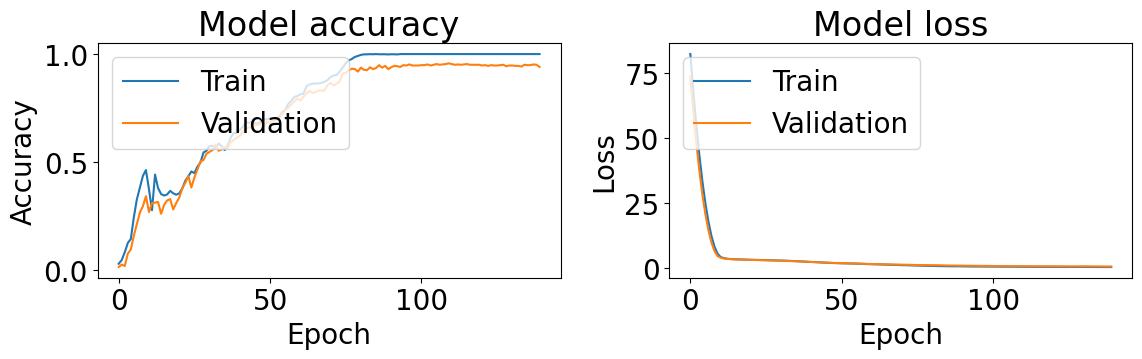

training history {'loss': [82.2866439819336, 67.71553039550781, 54.71529769897461, 43.247711181640625, 33.26823425292969, 24.785125732421875, 17.806459426879883, 12.300374984741211, 8.253121376037598, 5.629343032836914, 4.324547290802002, 3.9624557495117188, 3.7096879482269287, 3.5895488262176514, 3.5132808685302734, 3.468731641769409, 3.4277384281158447, 3.393228769302368, 3.353579521179199, 3.3253915309906006, 3.2803454399108887, 3.268040657043457, 3.2316300868988037, 3.1961724758148193, 3.1675660610198975, 3.142849922180176, 3.1056833267211914, 3.0801119804382324, 3.033034563064575, 3.009932279586792, 2.9923107624053955, 2.9491872787475586, 2.9012904167175293, 2.857496976852417, 2.7909586429595947, 2.7323803901672363, 2.691047430038452, 2.616978645324707, 2.562490940093994, 2.494032859802246, 2.4614005088806152, 2.390108346939087, 2.3253777027130127, 2.2575676441192627, 2.1979217529296875, 2.1396071910858154, 2.087230682373047, 2.0351407527923584, 2.008420467376709, 1.98555028438568

------------------------------------------------------------------------
Training for fold 2 ...
Epoch 1/200
10/10 [==============================] - 17s 141ms/step - loss: 82.0268 - accuracy: 0.0246 - val_loss: 73.3267 - val_accuracy: 0.0267 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 0s 47ms/step - loss: 67.4572 - accuracy: 0.0475 - val_loss: 59.6980 - val_accuracy: 0.0383 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 0s 48ms/step - loss: 54.4914 - accuracy: 0.0746 - val_loss: 47.6394 - val_accuracy: 0.0700 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 0s 48ms/step - loss: 43.0641 - accuracy: 0.1187 - val_loss: 37.0767 - val_accuracy: 0.0850 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 0s 47ms/step - loss: 33.1106 - accuracy: 0.1892 - val_loss: 27.9884 - val_accuracy: 0.1150 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 0s 47ms/step - loss: 24.6592 - accuracy: 0.

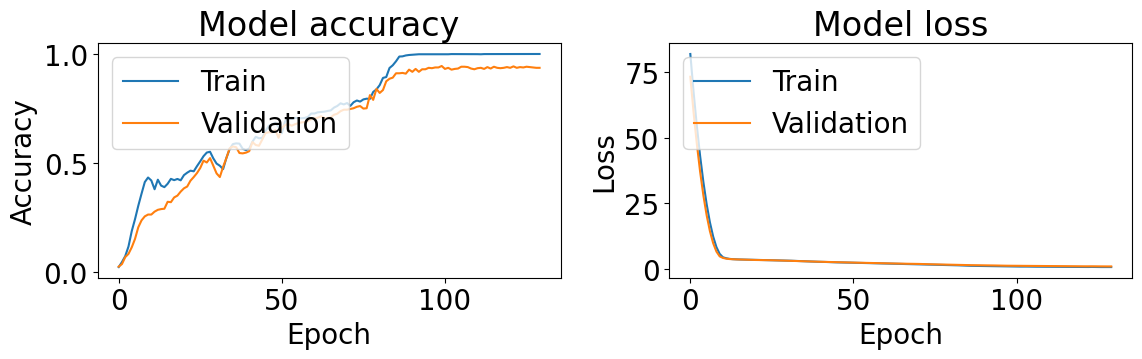

training history {'loss': [82.0268325805664, 67.45722198486328, 54.49141311645508, 43.06412124633789, 33.110565185546875, 24.659162521362305, 17.71270179748535, 12.249460220336914, 8.236518859863281, 5.618684768676758, 4.32760763168335, 3.9669322967529297, 3.720787763595581, 3.6044230461120605, 3.5390963554382324, 3.493084669113159, 3.464556932449341, 3.433410167694092, 3.397101879119873, 3.366809368133545, 3.32171893119812, 3.3016953468322754, 3.2890257835388184, 3.2634329795837402, 3.2471344470977783, 3.237973928451538, 3.2140023708343506, 3.1680047512054443, 3.145108222961426, 3.104173183441162, 3.055194616317749, 3.0050172805786133, 2.9534778594970703, 2.900230646133423, 2.8508973121643066, 2.789273977279663, 2.7463302612304688, 2.70419979095459, 2.6639175415039062, 2.61615252494812, 2.5952131748199463, 2.5596299171447754, 2.5098893642425537, 2.462749481201172, 2.4325499534606934, 2.381112575531006, 2.3638436794281006, 2.318380832672119, 2.307664155960083, 2.273287296295166, 2.2433

------------------------------------------------------------------------
Training for fold 3 ...
Epoch 1/200
10/10 [==============================] - 17s 142ms/step - loss: 82.0724 - accuracy: 0.0279 - val_loss: 73.3879 - val_accuracy: 0.0317 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 0s 47ms/step - loss: 67.5172 - accuracy: 0.0413 - val_loss: 59.7947 - val_accuracy: 0.0333 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 0s 47ms/step - loss: 54.5639 - accuracy: 0.0858 - val_loss: 47.7419 - val_accuracy: 0.0433 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 0s 47ms/step - loss: 43.1538 - accuracy: 0.1187 - val_loss: 37.2224 - val_accuracy: 0.0633 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 0s 47ms/step - loss: 33.2313 - accuracy: 0.1721 - val_loss: 28.1753 - val_accuracy: 0.1000 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 0s 48ms/step - loss: 24.8007 - accuracy: 0.

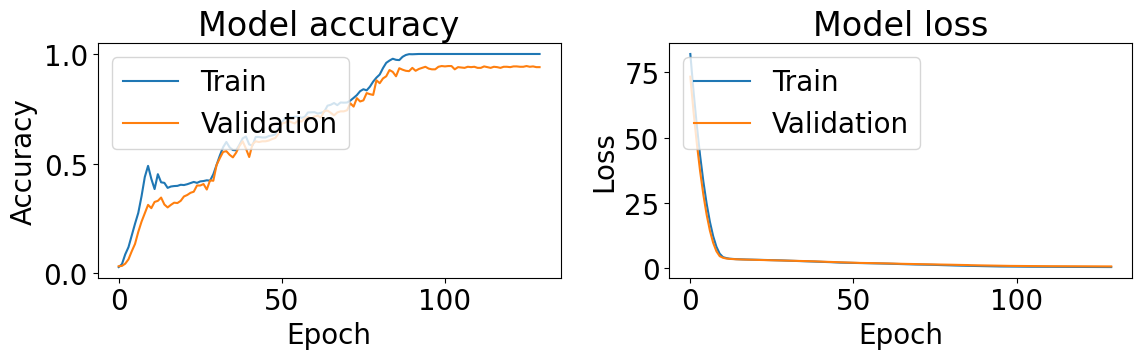

training history {'loss': [82.0724105834961, 67.51715850830078, 54.563926696777344, 43.153785705566406, 33.23125076293945, 24.8006591796875, 17.833206176757812, 12.349709510803223, 8.306982040405273, 5.650417804718018, 4.33640718460083, 3.9782750606536865, 3.734574317932129, 3.6234817504882812, 3.5533061027526855, 3.498706579208374, 3.4606375694274902, 3.428605556488037, 3.399388074874878, 3.380478620529175, 3.3574860095977783, 3.3307507038116455, 3.303250789642334, 3.2664976119995117, 3.243520736694336, 3.201836347579956, 3.164130449295044, 3.1238465309143066, 3.074390411376953, 3.0110793113708496, 2.973965644836426, 2.933039665222168, 2.8953824043273926, 2.8556225299835205, 2.817197322845459, 2.7629659175872803, 2.724316120147705, 2.697258949279785, 2.6578598022460938, 2.5950839519500732, 2.5573973655700684, 2.48882794380188, 2.4444360733032227, 2.403561592102051, 2.33296799659729, 2.275214195251465, 2.226940155029297, 2.196702480316162, 2.140345335006714, 2.104041576385498, 2.069632

------------------------------------------------------------------------
Training for fold 4 ...
Epoch 1/200
10/10 [==============================] - 17s 145ms/step - loss: 82.0825 - accuracy: 0.0362 - val_loss: 73.3731 - val_accuracy: 0.0550 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 0s 48ms/step - loss: 67.5164 - accuracy: 0.0479 - val_loss: 59.7344 - val_accuracy: 0.0733 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 0s 47ms/step - loss: 54.5522 - accuracy: 0.0637 - val_loss: 47.6626 - val_accuracy: 0.0833 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 0s 39ms/step - loss: 43.1200 - accuracy: 0.0967 - val_loss: 37.1009 - val_accuracy: 0.0683 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 0s 36ms/step - loss: 33.1805 - accuracy: 0.1892 - val_loss: 28.0630 - val_accuracy: 0.0750 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 0s 48ms/step - loss: 24.7281 - accuracy: 0.

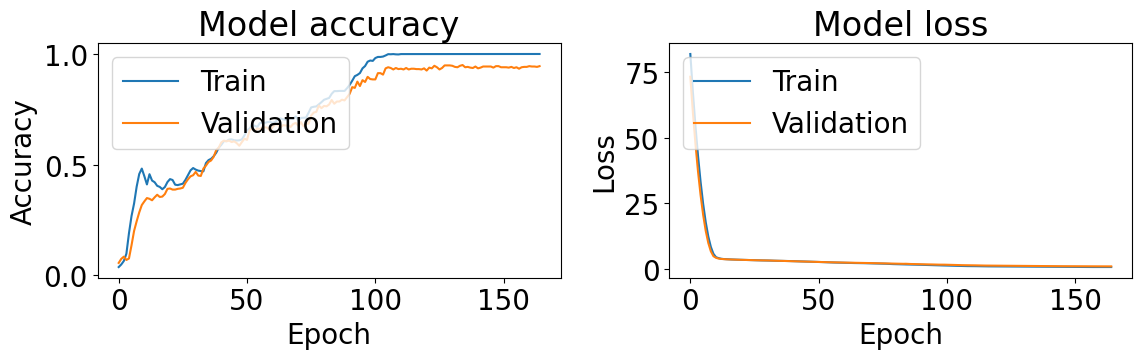

training history {'loss': [82.0824966430664, 67.51641082763672, 54.5522346496582, 43.120025634765625, 33.180519104003906, 24.728126525878906, 17.767141342163086, 12.283310890197754, 8.262846946716309, 5.6332011222839355, 4.337205410003662, 3.9783830642700195, 3.730478048324585, 3.6202986240386963, 3.5539233684539795, 3.5097787380218506, 3.4584081172943115, 3.412846088409424, 3.3833205699920654, 3.3523190021514893, 3.320049285888672, 3.2860841751098633, 3.2457127571105957, 3.217299699783325, 3.1800167560577393, 3.157719373703003, 3.141026496887207, 3.1045303344726562, 3.0911178588867188, 3.081822395324707, 3.0541489124298096, 3.01857328414917, 3.004481315612793, 2.9715487957000732, 2.948606491088867, 2.9342041015625, 2.906470537185669, 2.881718873977661, 2.860703229904175, 2.842285633087158, 2.813206672668457, 2.7827327251434326, 2.760423421859741, 2.7375175952911377, 2.7162625789642334, 2.6871497631073, 2.652712345123291, 2.604485511779785, 2.571329116821289, 2.517683982849121, 2.49234

------------------------------------------------------------------------
Training for fold 5 ...
Epoch 1/200
10/10 [==============================] - 19s 144ms/step - loss: 82.2857 - accuracy: 0.0321 - val_loss: 73.5627 - val_accuracy: 0.0433 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 0s 48ms/step - loss: 67.7141 - accuracy: 0.0446 - val_loss: 59.9246 - val_accuracy: 0.0483 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 0s 47ms/step - loss: 54.7346 - accuracy: 0.0871 - val_loss: 47.8409 - val_accuracy: 0.0550 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 0s 48ms/step - loss: 43.2757 - accuracy: 0.1246 - val_loss: 37.2750 - val_accuracy: 0.0750 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 0s 49ms/step - loss: 33.3240 - accuracy: 0.2046 - val_loss: 28.2126 - val_accuracy: 0.1100 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 0s 49ms/step - loss: 24.8531 - accuracy: 0.

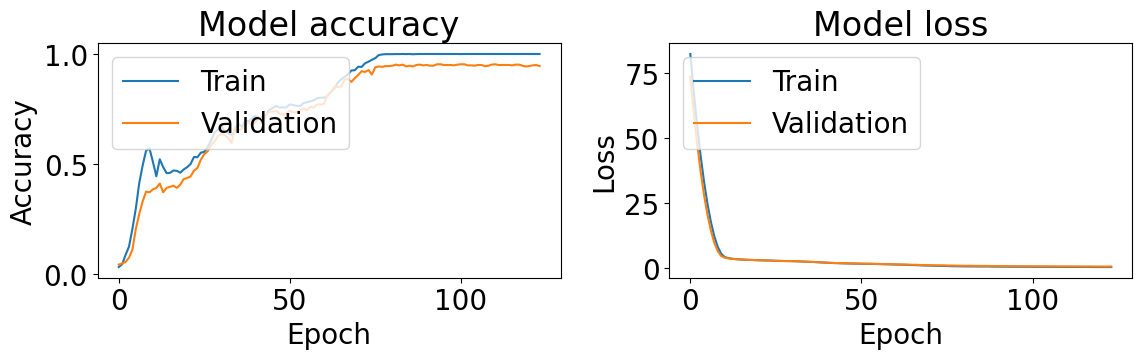

training history {'loss': [82.28568267822266, 67.71410369873047, 54.734622955322266, 43.27570343017578, 33.32400894165039, 24.853137969970703, 17.868070602416992, 12.340792655944824, 8.270951271057129, 5.631232261657715, 4.330934524536133, 3.951312303543091, 3.6887755393981934, 3.548375129699707, 3.4252970218658447, 3.3552091121673584, 3.2954397201538086, 3.2217981815338135, 3.183901071548462, 3.1266515254974365, 3.0939855575561523, 3.041949510574341, 3.0125794410705566, 2.988626718521118, 2.928213357925415, 2.8662447929382324, 2.8369979858398438, 2.8021907806396484, 2.767285108566284, 2.752929210662842, 2.7248473167419434, 2.6798057556152344, 2.638239622116089, 2.571789026260376, 2.5094974040985107, 2.466667413711548, 2.4136602878570557, 2.3461031913757324, 2.2758095264434814, 2.1928703784942627, 2.1301541328430176, 2.0540385246276855, 1.9974653720855713, 1.9548394680023193, 1.9008331298828125, 1.869753360748291, 1.842987060546875, 1.7989020347595215, 1.7826368808746338, 1.74481606483

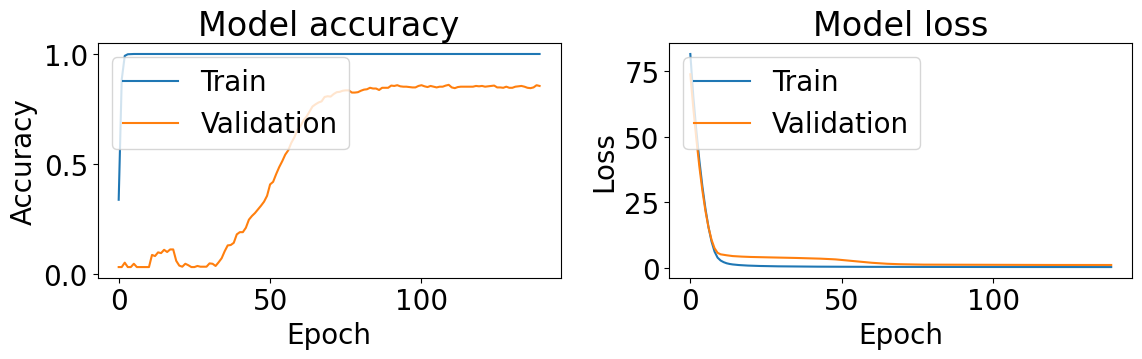

training history {'loss': [81.6085433959961, 65.2365493774414, 52.149967193603516, 40.827049255371094, 30.938079833984375, 22.48470687866211, 15.507434844970703, 10.061339378356934, 6.177696704864502, 3.8647079467773438, 2.765869379043579, 2.1367082595825195, 1.704832911491394, 1.4406331777572632, 1.2621017694473267, 1.1346338987350464, 1.034060001373291, 0.9538993239402771, 0.884389340877533, 0.8277714848518372, 0.779123067855835, 0.7411236763000488, 0.7064144611358643, 0.6740860939025879, 0.6459805369377136, 0.6209690570831299, 0.5958012938499451, 0.5783979892730713, 0.5592679977416992, 0.5410541296005249, 0.5285961031913757, 0.5124481916427612, 0.49976226687431335, 0.48757287859916687, 0.47669127583503723, 0.46708181500434875, 0.45862939953804016, 0.4492490589618683, 0.4407377541065216, 0.43367254734039307, 0.4280562698841095, 0.42278698086738586, 0.4155759811401367, 0.4092103838920593, 0.404520720243454, 0.3979959487915039, 0.39376336336135864, 0.3887728750705719, 0.385264158248901

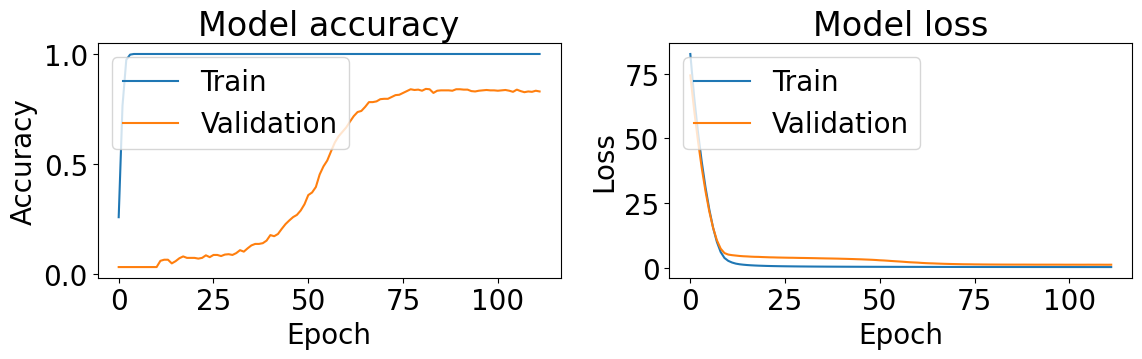

training history {'loss': [82.62962341308594, 66.2108383178711, 52.629947662353516, 41.116512298583984, 31.122037887573242, 22.577011108398438, 15.519213676452637, 10.01160717010498, 6.100869178771973, 3.7977538108825684, 2.6757495403289795, 2.032364845275879, 1.6051870584487915, 1.3522460460662842, 1.18498957157135, 1.0554704666137695, 0.9583125710487366, 0.8794304132461548, 0.8149753212928772, 0.7673434615135193, 0.7180605530738831, 0.681435763835907, 0.6490681171417236, 0.6211369037628174, 0.5956223607063293, 0.5740585327148438, 0.5563464760780334, 0.5384013652801514, 0.523556649684906, 0.5083181858062744, 0.497545063495636, 0.48393329977989197, 0.47436776757240295, 0.4642544984817505, 0.456447958946228, 0.44772765040397644, 0.4385009706020355, 0.43209758400917053, 0.42565321922302246, 0.41967952251434326, 0.4139474332332611, 0.40771687030792236, 0.4019033908843994, 0.3969302177429199, 0.3918032646179199, 0.3865652084350586, 0.3830650746822357, 0.37780722975730896, 0.374341189861297

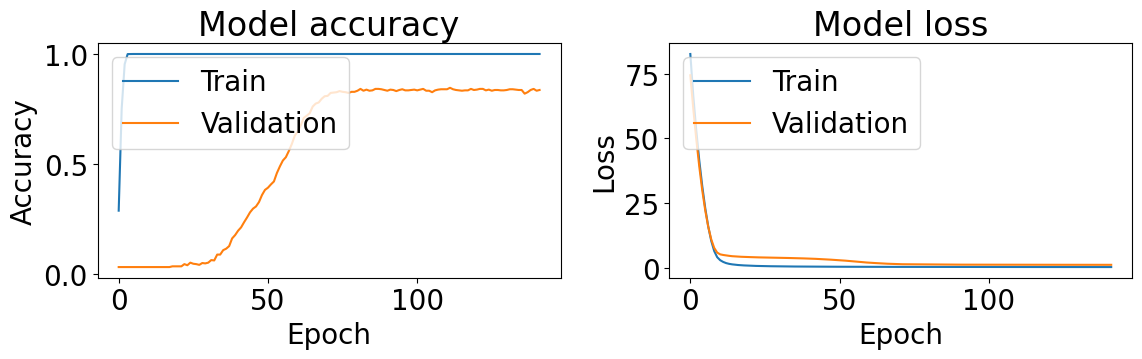

training history {'loss': [82.6540756225586, 66.35768127441406, 52.961036682128906, 41.496482849121094, 31.558935165405273, 23.04277229309082, 15.975937843322754, 10.416051864624023, 6.466055870056152, 4.082353591918945, 2.9228248596191406, 2.2550442218780518, 1.7946020364761353, 1.5073530673980713, 1.3123990297317505, 1.1667158603668213, 1.0554144382476807, 0.9680676460266113, 0.8988836407661438, 0.8412696123123169, 0.7899698615074158, 0.7445364594459534, 0.7088385224342346, 0.675737738609314, 0.6500889658927917, 0.6233466863632202, 0.6015914678573608, 0.5820035338401794, 0.5637734532356262, 0.5473113059997559, 0.532015860080719, 0.5187754034996033, 0.5066900849342346, 0.4935467541217804, 0.4840225279331207, 0.4735572338104248, 0.46457022428512573, 0.4559924900531769, 0.4481215476989746, 0.4404999315738678, 0.4352104067802429, 0.4279313087463379, 0.42249733209609985, 0.4161509573459625, 0.41023367643356323, 0.40535667538642883, 0.40075117349624634, 0.3976919949054718, 0.39229971170425

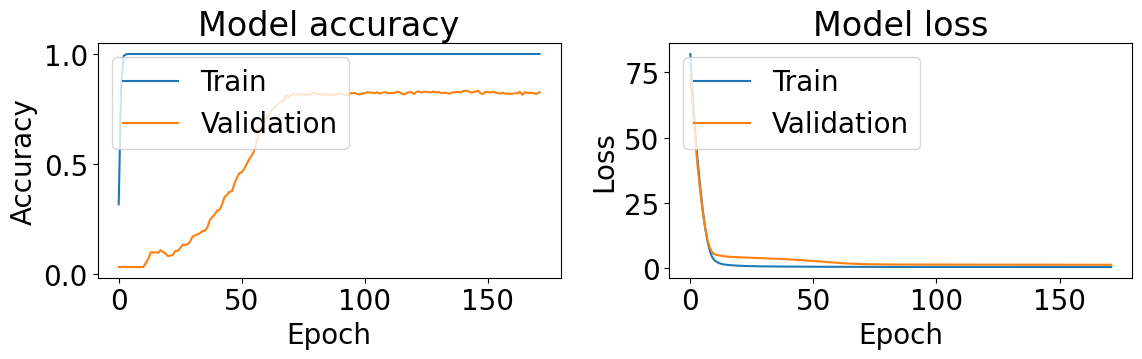

training history {'loss': [82.0730209350586, 65.64324188232422, 52.420799255371094, 41.0156364440918, 31.07161521911621, 22.548267364501953, 15.52603816986084, 10.04748249053955, 6.153135776519775, 3.8261661529541016, 2.717452049255371, 2.076122522354126, 1.64747154712677, 1.3901439905166626, 1.2169872522354126, 1.091368556022644, 0.9898836016654968, 0.9107726812362671, 0.8493683934211731, 0.7923903465270996, 0.7465482354164124, 0.706571102142334, 0.6700648665428162, 0.6384311318397522, 0.6119289994239807, 0.5899743437767029, 0.5696020126342773, 0.5500718355178833, 0.5352135896682739, 0.5206543207168579, 0.505706250667572, 0.4925082325935364, 0.4841572642326355, 0.473472535610199, 0.46246087551116943, 0.45393234491348267, 0.4459390640258789, 0.43900421261787415, 0.43156662583351135, 0.42477327585220337, 0.4199727177619934, 0.4140368103981018, 0.40747469663619995, 0.4026797115802765, 0.397300660610199, 0.39434394240379333, 0.38918134570121765, 0.38599899411201477, 0.38125094771385193, 0

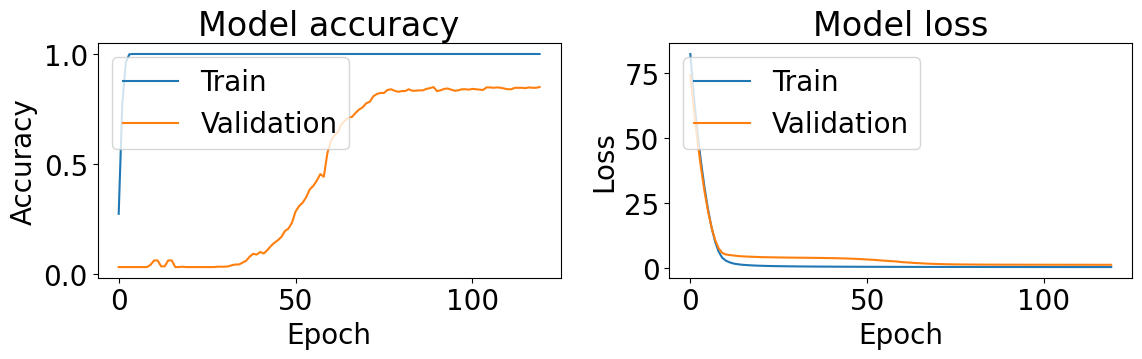

training history {'loss': [82.27721405029297, 65.86121368408203, 52.40068054199219, 40.941837310791016, 31.01788330078125, 22.540969848632812, 15.561161994934082, 10.105823516845703, 6.217599391937256, 3.8951058387756348, 2.7837018966674805, 2.145808458328247, 1.7064622640609741, 1.4399691820144653, 1.2575701475143433, 1.1279464960098267, 1.0280556678771973, 0.9452630877494812, 0.8774858713150024, 0.8190715312957764, 0.7720355987548828, 0.7305484414100647, 0.6948308348655701, 0.6645676493644714, 0.638894259929657, 0.6121411919593811, 0.5939010381698608, 0.5728309750556946, 0.5576378107070923, 0.5417553782463074, 0.5265777707099915, 0.5135517716407776, 0.5001253485679626, 0.4885903000831604, 0.47793707251548767, 0.4688589572906494, 0.46004506945610046, 0.45186853408813477, 0.4454784691333771, 0.43702200055122375, 0.431228905916214, 0.42327991127967834, 0.4180358052253723, 0.4125531017780304, 0.4062829613685608, 0.4012559950351715, 0.3955117166042328, 0.3914380967617035, 0.38838496804237

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import random
import os
import numpy as np
import tensorflow as tf

# Imposta i seed per la riproducibilità
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # tf.config.experimental.enable_op_determinism() # Rimuovi il commento per un determinismo assoluto (può rallentare il training)

set_seeds(42)

temp_model = -1

def do_experiment(finetune_percent = 0.2, use_selfsupervised_backbone = True, nfolds_to_test=5):
  use_reference_warmup = False  # should we train few epochs with x_reference


  if finetune_percent < 1.0:
    xtrainpct, xtestpct, ytrainpct, ytestpct = train_test_split(x_finetune, y_finetune,
                                                                train_size=finetune_percent, random_state=42,
                                                                stratify=y_finetune,
                                                                shuffle=True)
    x_finetune_select, y_finetune_select = xtrainpct, ytrainpct
  else:
    x_finetune_select, y_finetune_select = x_finetune, y_finetune


  # fold validation and testing
  num_folds=5
  kfold = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

  # K-fold Cross Validation model evaluation
  fold_no = 1
  for train_indices, val_indices in kfold.split(x_finetune_select, y_finetune_select):
      # Generate batches from indices
      xtrain, xval = x_finetune_select[train_indices], x_finetune_select[val_indices]
      ytrain, yval = y_finetune_select[train_indices], y_finetune_select[val_indices]
      if use_selfsupervised_backbone:
        # CARICAMENTO DEL TUO MODELLO PRE-ADDESTRATO
        bm_model_loaded = keras.models.load_model("/content/drive/My Drive/Tesi_Raman/Models/PreTrain/BarlowTwins/1000pt/FullRange/Min-Max/exp_3/ramanfoundation_pretrained_model.h5")
      else:
        bm_model_loaded = build_twin() # use random weights model

      # Do not freeze weights
      model = tf.keras.models.Sequential([
        bm_model_loaded,
        tf.keras.layers.Dense(
            30,
            activation="softmax",
            kernel_regularizer=tf.keras.regularizers.L1L2(0.05,0.05)
        )
      ])

      # Generate a print
      print('------------------------------------------------------------------------')
      print(f'Training for fold {fold_no} ...')

      if use_reference_warmup:
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.5, beta_2=0.999), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        history=model.fit(x_reference, y_reference, batch_size=512, epochs=5,
                                          callbacks=[
                                keras.callbacks.EarlyStopping(
                                    monitor='val_accuracy',
                                    patience=10,
                                    restore_best_weights=True
                                ),
                                keras.callbacks.ReduceLROnPlateau(
                                    monitor='val_loss',
                                    factor=0.1,
                                    patience=30,
                                    min_lr=0.0000005
                                )
                            ], validation_split=0.2
        )

        # Plot training history
        import matplotlib.pyplot as plt

        plt.figure(figsize=(12, 4))

        # Plot training & validation accuracy
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'])
        plt.plot(history.history['val_accuracy'])
        plt.title('Model accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')

        # Plot training & validation loss
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'])
        plt.plot(history.history['val_loss'])
        plt.title('Model loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')

        plt.tight_layout()
        plt.show()

        print("train with xref and yref light")
        model.evaluate(x_test, y_test)

      model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0005, beta_1=0.9, beta_2=0.999), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

      history = model.fit(xtrain, ytrain,
                          validation_data=(xval, yval),
                          # 256
                          batch_size=256,
                          epochs=200,
                          callbacks=[
                              keras.callbacks.EarlyStopping(
                                  monitor='val_accuracy',
                                  patience=30,
                                  restore_best_weights=True
                              ),
                              keras.callbacks.ReduceLROnPlateau(
                                  monitor='val_loss',
                                  factor=0.1,
                                  patience=30,
                                  min_lr=0.0000005
                              )
                          ]
                          #validation_split=0.2
                          )

      # Plot training history
      import matplotlib.pyplot as plt
      plt.figure(figsize=(12, 4))

      # Plot training & validation accuracy
      plt.subplot(1, 2, 1)
      plt.plot(history.history['accuracy'])
      plt.plot(history.history['val_accuracy'])
      plt.title('Model accuracy')
      plt.ylabel('Accuracy')
      plt.xlabel('Epoch')
      plt.legend(['Train', 'Validation'], loc='upper left')

      # Plot training & validation loss
      plt.subplot(1, 2, 2)
      plt.plot(history.history['loss'])
      plt.plot(history.history['val_loss'])
      plt.title('Model loss')
      plt.ylabel('Loss')
      plt.xlabel('Epoch')
      plt.legend(['Train', 'Validation'], loc='upper left')

      plt.tight_layout()
      plt.show()
      history_str = str(history.history)
      print (f"training history {history_str}")


      result = model.evaluate(x_test, y_test)
      result_str = "test loss, test acc:" + str(result)
      print(f"Result: use backbone : {use_selfsupervised_backbone}, test_accuracy finetune_percent {finetune_percent}, fold_number {fold_no}, test_results {result_str}")
      result_dict = dict(zip(model.metrics_names, result))
      result_dict_str = str(result_dict)
      print(result_dict_str)

      # save result_dict_str into a txt file
      file_name = f"result_{int(finetune_percent * 100)}_backbone_{use_selfsupervised_backbone}"

      # Save the string to a file
      with open(file_name, "a") as file:
          file.write("\n"+result_dict_str)

      print(f"String saved to {file_name}")

      # You can utilize temp_model for creating certain plots like confusion matricies
      global temp_model
      temp_model = model

      fold_no = fold_no + 1
      if fold_no > nfolds_to_test:
        return

# Esegue solo per il 100% dei dati
for pct in [100]:
  for usebackbone in [True, False]:
    print (f"Running finetune_pct  {pct} usebackbone {usebackbone}")
    do_experiment(pct/100.0, usebackbone,  nfolds_to_test=5)


In [22]:
import ast
import os
import numpy as np

print("=== AVERAGE ACCURACY SUMMARY ===\n")

# Analizza solo il file dei risultati per il 100% dei dati
for pct in [100]:
    for usebackbone in [True, False]:
        file_name = f"result_{pct}_backbone_{usebackbone}"
        if os.path.exists(file_name):
            with open(file_name, "r") as f:
                lines = f.readlines()
                accuracies = []
                for line in lines:
                    line = line.strip()
                    if line:
                        try:
                            # Convert the dictionary string into a real Python dictionary
                            result_dict = ast.literal_eval(line)
                            accuracies.append(result_dict['accuracy'])
                        except:
                            pass

                if accuracies:
                    avg_acc = np.mean(accuracies)
                    std_acc = np.std(accuracies)
                    print(f"-> Data used: {pct}% | Pre-trained (Backbone): {usebackbone}")
                    print(f"   Average Test Accuracy: {avg_acc*100:.2f}% (± {std_acc*100:.2f}%)\n")
        else:
            print(f"File {file_name} not found.\n")


=== AVERAGE ACCURACY SUMMARY ===

-> Data used: 100% | Pre-trained (Backbone): True
   Average Test Accuracy: 79.88% (± 1.11%)

-> Data used: 100% | Pre-trained (Backbone): False
   Average Test Accuracy: 72.11% (± 1.05%)



In [23]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 20}) # Adjust the value (20) as needed

Confusion matrix plot used in Figure 8

94/94 [==============================] - 1s 4ms/step


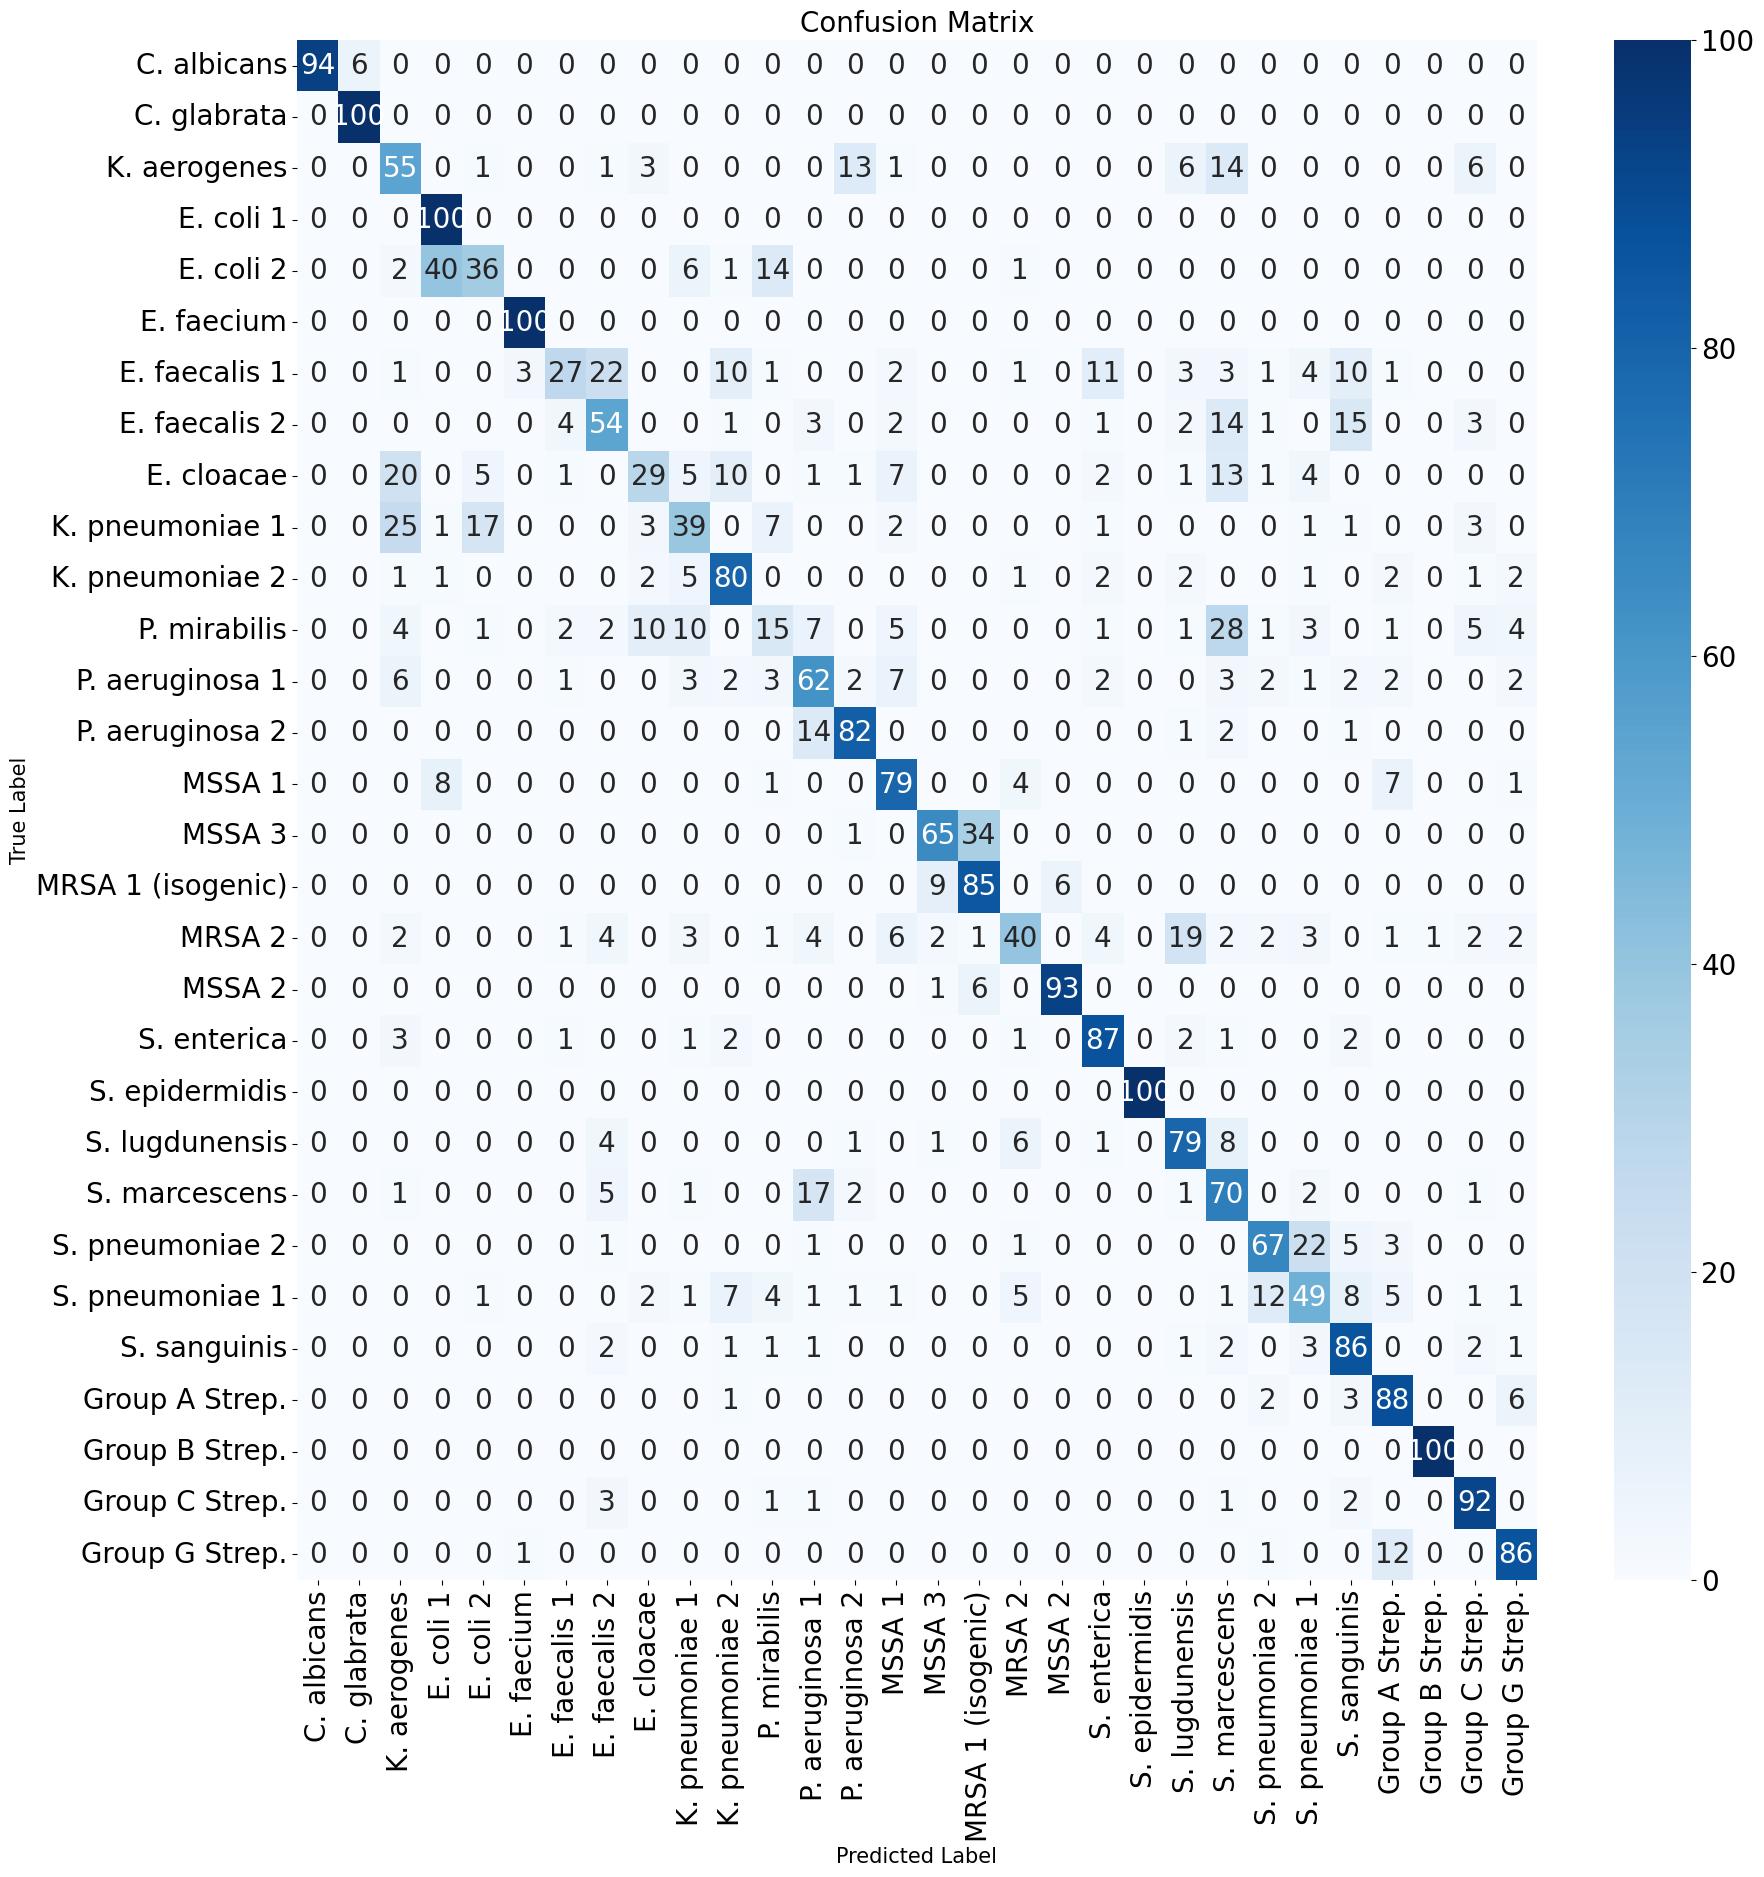

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


y_pred = np.argmax(temp_model.predict(x_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[STRAINS[i] for i in range(30)],
            yticklabels=[STRAINS[i] for i in range(30)])
plt.xlabel("Predicted Label", fontsize=FONTSIZE_AXIS)
plt.ylabel("True Label", fontsize=FONTSIZE_AXIS)
plt.title("Confusion Matrix", fontsize=FONTSIZE_TITLE)
plt.show()